# Güçlendirilmiş Klasik Transformer Modeli

Bu notebook, Transformer modelini SVM, CNN/MLP, ANN ve LSTM modelleriyle daha adil karşılaştırılabilecek aynı deneysel akışa göre düzenler.

Akış:

`EfficientNet-B0 özellik çıkarımı → StandardScaler → PCA(256) → PCA sonrası StandardScaler → klasik Transformer Encoder → 5 katlı Stratified K-Fold hiperparametre araması → sınıf bazlı doğru/yanlış tablo`

Model tamamen klasiktir; kuantum katman içermez.


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 15.9 MB/s eta 0:00:00
Kullanılan cihaz: cpu
Sınıf eşlemesi: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}

Kayıtlı train/test ayrımı kontrol ediliyor.
Kayıtlı train/test ayrımı yüklendi ve dosya yolları geçerli.

Sınıf bazlı toplam görüntü sayısı:


,Sınıf,Görüntü sayısı
0,glioma_tumor,926
1,meningioma_tumor,937
2,no_tumor,500
3,pituitary_tumor,901



Eğitim görüntü sayısı: 2609
Test görüntü sayısı   : 655
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 118MB/s] 



Feature extractor: EfficientNet-B0
Ham özellik boyutu: 1280

Kayıtlı EfficientNet-B0 özellikleri yükleniyor:
/content/drive/MyDrive/Beyin_MR_Kuantum_Makale/cache_classical_cnn_strong_mlp/efficientnet_b0_features_seed42_img224.npz

Ham özellik şekilleri:
X_train_raw: (2609, 1280)
X_test_raw : (655, 1280)

PCA sonrası özellik şekilleri:
X_train_features: (2609, 256)
X_test_features : (655, 256)
PCA açıklanan varyans: 0.8574

5 KATLI STRATIFIED K-FOLD HİPERPARAMETRE ARAMA BAŞLIYOR

--- Konfigürasyon: tr_s16_d32_h4_l1_ff128_do020_lr7e-4 ---
Fold 1/5 | Best Val Macro-F1: 0.9213 | Best Epoch: 27
Fold 2/5 | Best Val Macro-F1: 0.8852 | Best Epoch: 7
Fold 3/5 | Best Val Macro-F1: 0.9107 | Best Epoch: 16
Fold 4/5 | Best Val Macro-F1: 0.9110 | Best Epoch: 13
Fold 5/5 | Best Val Macro-F1: 0.8947 | Best Epoch: 9

--- Konfigürasyon: tr_s16_d32_h4_l2_ff128_do025_lr5e-4 ---
Fold 1/5 | Best Val Macro-F1: 0.9191 | Best Epoch: 9
Fold 2/5 | Best Val Macro-F1: 0.9023 | Best Epoch: 30
Fold 3/5 | Best Val M

...

,Dosya yolu,Dosya adı,Gerçek sınıf,Tahmin edilen sınıf,Sonuç,Tahmin güveni,Gerçek sınıf olasılığı,Tahmin edilen sınıf olasılığı
0,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,gg (272).jpg,glioma_tumor,glioma_tumor,Doğru,0.9856,0.9856,0.9856
1,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,m1(57).jpg,meningioma_tumor,glioma_tumor,Yanlış,0.9794,0.0129,0.9794
2,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,gg (374).jpg,glioma_tumor,glioma_tumor,Doğru,0.9863,0.9863,0.9863
3,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,T105.jpg,no_tumor,no_tumor,Doğru,0.9949,0.9949,0.9949
4,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,gg (321).jpg,glioma_tumor,glioma_tumor,Doğru,0.9729,0.9729,0.9729
...,...,...,...,...,...,...,...,...
650,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,image(27).jpg,glioma_tumor,glioma_tumor,Doğru,0.9826,0.9826,0.9826
651,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,m3 (155).jpg,meningioma_tumor,meningioma_tumor,Doğru,0.9823,0.9823,0.9823
652,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,m (186).jpg,meningioma_tumor,meningioma_tumor,Doğru,0.9693,0.9693,0.9693
653,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,gg (492).jpg,glioma_tumor,glioma_tumor,Doğru,0.9863,0.9863,0.9863



Görüntü bazlı detaylı test sonuçları kaydedildi:
/content/drive/MyDrive/Beyin_MR_Kuantum_Makale/cache_classical_transformer_strong_fair/test_goruntu_bazli_sonuclar.csv

SADECE YANLIŞ TAHMİN EDİLEN TEST GÖRÜNTÜLERİ


,Dosya yolu,Dosya adı,Gerçek sınıf,Tahmin edilen sınıf,Sonuç,Tahmin güveni,Gerçek sınıf olasılığı,Tahmin edilen sınıf olasılığı
1,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,m1(57).jpg,meningioma_tumor,glioma_tumor,Yanlış,0.9794,0.0129,0.9794
5,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,m3 (77).jpg,meningioma_tumor,glioma_tumor,Yanlış,0.9497,0.0435,0.9497
18,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,image(193).jpg,no_tumor,glioma_tumor,Yanlış,0.9813,0.0059,0.9813
19,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,gg (368).jpg,glioma_tumor,no_tumor,Yanlış,0.9901,0.0037,0.9901
27,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,gg (653).jpg,glioma_tumor,meningioma_tumor,Yanlış,0.6124,0.3774,0.6124
31,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,image(33).jpg,glioma_tumor,no_tumor,Yanlış,0.5383,0.0025,0.5383
50,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,image(196).jpg,no_tumor,glioma_tumor,Yanlış,0.9295,0.0509,0.9295
56,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,gg (16).jpg,glioma_tumor,meningioma_tumor,Yanlış,0.9683,0.0243,0.9683
67,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,m (38).jpg,meningioma_tumor,glioma_tumor,Yanlış,0.9729,0.0208,0.9729
77,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,gg (701).jpg,glioma_tumor,meningioma_tumor,Yanlış,0.9594,0.0335,0.9594



CLASSIFICATION REPORT
                  precision    recall  f1-score   support

    glioma_tumor     0.9121    0.8925    0.9022       186
meningioma_tumor     0.8836    0.8883    0.8859       188
        no_tumor     0.9579    0.9100    0.9333       100
 pituitary_tumor     0.9524    0.9945    0.9730       181

        accuracy                         0.9221       655
       macro avg     0.9265    0.9213    0.9236       655
    weighted avg     0.9220    0.9221    0.9218       655



<Figure size 800x600 with 0 Axes>

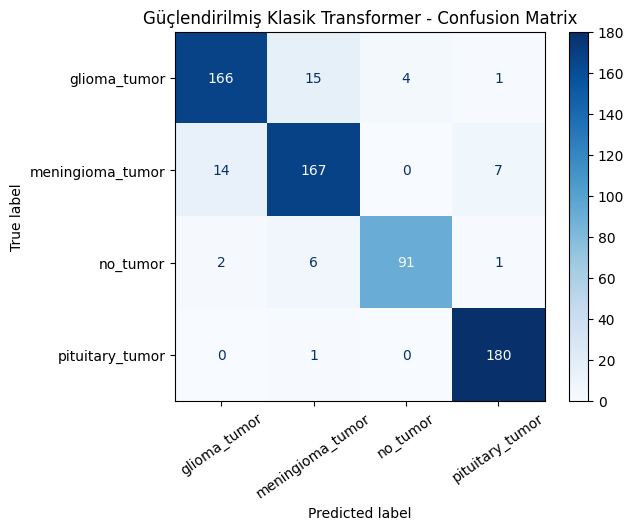

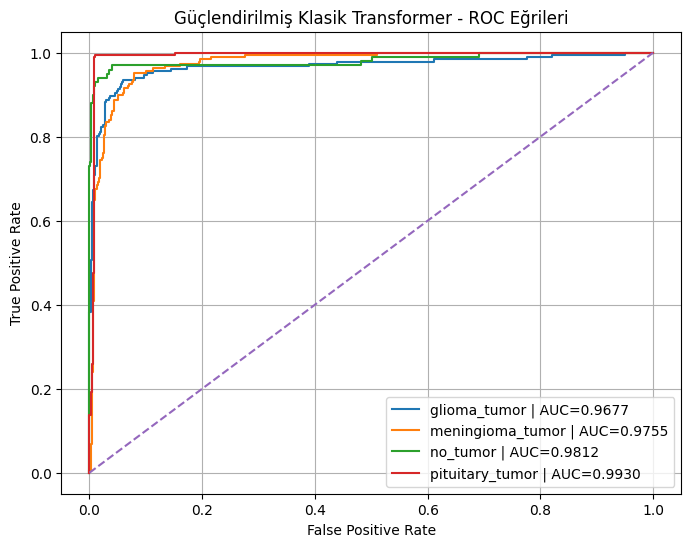


MAKALE / SLAYT İÇİN KISA ÖZET

Güçlendirilmiş klasik Transformer modelinde, MR görüntülerinden önceden eğitilmiş
EfficientNet-B0 modeli ile 1280 boyutlu derin öznitelikler çıkarılmıştır.
Bu öznitelikler önce standartlaştırılmış, ardından PCA ile 256 boyuta
indirgenmiş ve PCA sonrası tekrar standartlaştırılmıştır. Sınıflandırma aşamasında,
PCA bileşenleri öğrenilebilir bir token dizisine dönüştürülmüş ve tamamen klasik
Transformer Encoder tabanlı sınıflandırıcı kullanılmıştır. Bu modelde kuantum katman,
qubit veya kuantum devre bulunmamaktadır.
Hiperparametreler 5 katlı Stratified K-Fold doğrulama ile Macro-F1 ölçütüne göre seçilmiştir.

Test kümesindeki toplam 655 görüntünün 604 tanesi doğru,
51 tanesi yanlış sınıflandırılmıştır. Modelin genel test doğruluğu
0.9221, Macro-F1 değeri 0.9236 olarak elde edilmiştir.



In [1]:
# ============================================================
# GÜÇLENDİRİLMİŞ KLASİK TRANSFORMER KARŞILAŞTIRMA MODELİ
# DÜZELTME: Data/Training + Data/Testing klasör yapısı otomatik algılanır
# Transformer modeli, SVM/CNN/ANN/LSTM ile adil karşılaştırma yapılabilmesi için
# aynı güçlü deneysel akışa göre yeniden düzenlenmiştir:
# EfficientNet-B0 özellik çıkarımı + StandardScaler + PCA(256)
# + PCA sonrası StandardScaler + 5 katlı StratifiedKFold ile
# hiperparametre seçimi + klasik Transformer Encoder sınıflandırıcı kullanılır.
#
# Not: Bu model klasik / hibrit olmayan bir modeldir; kuantum katman içermez.
# Test verilerinde sınıf bazlı doğru / yanlış tahmin tablosu dahil.
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

# ============================================================
# 1) KURULUMLAR
# ============================================================
!pip -q install --upgrade pip
!pip -q install torchvision scikit-learn pandas tqdm matplotlib joblib openpyxl

# ============================================================
# 2) IMPORTLAR
# ============================================================
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset

import torchvision.transforms as T
import torchvision.models as models

import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
from sklearn.utils.class_weight import compute_class_weight

# ============================================================
# 3) GENEL AYARLAR
# ============================================================
SEED = 42


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Kullanılan cihaz:", DEVICE)

# Burayı kendi veri klasörüne göre kontrol et
DATA_ROOT = "/content/drive/MyDrive/Beyin_MR_Kuantum_Makale/Data"

CLASS_NAMES = [
    "glioma_tumor",
    "meningioma_tumor",
    "no_tumor",
    "pituitary_tumor"
]

CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: cls for cls, i in CLASS_TO_IDX.items()}
N_CLASSES = len(CLASS_NAMES)

CLASS_DIRS = {cls: os.path.join(DATA_ROOT, cls) for cls in CLASS_NAMES}

IMG_SIZE = 224
TEST_SIZE = 0.20

FEATURE_BATCH_SIZE = 64
PCA_COMPONENTS = 256

# SVM/CNN/ANN/LSTM'deki güçlü yapı ile benzer biçimde Transformer hiperparametre araması yapılır.
N_FOLDS = 5
SEARCH_MAX_EPOCHS = 45
SEARCH_PATIENCE = 7
FINAL_MIN_EPOCHS = 8

FORCE_REEXTRACT_IMAGE_FEATURES = False

CACHE_DIR = "/content/drive/MyDrive/Beyin_MR_Kuantum_Makale/cache_classical_transformer_strong_fair"
os.makedirs(CACHE_DIR, exist_ok=True)

# Adil karşılaştırma için son oluşturulan güçlü CNN/MLP modeliyle aynı
# train/test ayrımı ve aynı EfficientNet-B0 özellik cache'i varsa onu kullanır.
REFERENCE_CNN_CACHE_DIR = "/content/drive/MyDrive/Beyin_MR_Kuantum_Makale/cache_classical_cnn_strong_mlp"
REFERENCE_FEATURE_CACHE_PATH = os.path.join(
    REFERENCE_CNN_CACHE_DIR,
    f"efficientnet_b0_features_seed{SEED}_img{IMG_SIZE}.npz"
)
REFERENCE_TRAIN_SPLIT_PATH = os.path.join(REFERENCE_CNN_CACHE_DIR, "train_split.csv")
REFERENCE_TEST_SPLIT_PATH = os.path.join(REFERENCE_CNN_CACHE_DIR, "test_split.csv")

LOCAL_FEATURE_CACHE_PATH = os.path.join(CACHE_DIR, f"efficientnet_b0_features_seed{SEED}_img{IMG_SIZE}.npz")
LOCAL_TRAIN_SPLIT_PATH = os.path.join(CACHE_DIR, "train_split.csv")
LOCAL_TEST_SPLIT_PATH = os.path.join(CACHE_DIR, "test_split.csv")

FEATURE_CACHE_PATH = REFERENCE_FEATURE_CACHE_PATH if os.path.exists(REFERENCE_FEATURE_CACHE_PATH) else LOCAL_FEATURE_CACHE_PATH
TRAIN_SPLIT_PATH = REFERENCE_TRAIN_SPLIT_PATH if os.path.exists(REFERENCE_TRAIN_SPLIT_PATH) else LOCAL_TRAIN_SPLIT_PATH
TEST_SPLIT_PATH = REFERENCE_TEST_SPLIT_PATH if os.path.exists(REFERENCE_TEST_SPLIT_PATH) else LOCAL_TEST_SPLIT_PATH

MODEL_SAVE_PATH = os.path.join(CACHE_DIR, "strong_classical_transformer_model.pt")
SCALER_PCA_SAVE_PATH = os.path.join(CACHE_DIR, "transformer_scaler_pca_post_scaler.joblib")
SEARCH_RESULTS_PATH = os.path.join(CACHE_DIR, "transformer_hyperparametre_arama_sonuclari.csv")
DETAIL_TEST_RESULTS_PATH = os.path.join(CACHE_DIR, "test_goruntu_bazli_sonuclar.csv")
CLASS_SUMMARY_PATH = os.path.join(CACHE_DIR, "sinif_bazli_dogru_yanlis_sonuclar.csv")
CONFUSION_DETAIL_PATH = os.path.join(CACHE_DIR, "siniflar_arasi_karisiklik_tablosu.csv")

print("Sınıf eşlemesi:", CLASS_TO_IDX)

# ============================================================
# 4) VERİLERİ LİSTELEME VE 80/20 BÖLME
# ============================================================
# Bu bölüm hata almamak için esnek hale getirildi.
# Aşağıdaki iki veri klasörü düzenini de destekler:
# 1) Data/glioma_tumor, Data/meningioma_tumor, ...
# 2) Data/Training/glioma_tumor + Data/Testing/glioma_tumor, ...
# İkinci düzende Training ve Testing klasörleri önce birleştirilir,
# sonra tüm modellerle adil karşılaştırma için yine sınıf bazlı 80/20 bölme yapılır.

IMAGE_EXTS = (".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff")


def list_images(folder, warn=False):
    files = []

    if not os.path.isdir(folder):
        if warn:
            print("UYARI: Klasör bulunamadı:", folder)
        return files

    for root, _, names in os.walk(folder):
        for name in names:
            if name.lower().endswith(IMAGE_EXTS):
                files.append(os.path.join(root, name))

    return sorted(files)


def collect_class_files(data_root, class_names):
    """Veri klasörünü otomatik algılar ve her sınıf için dosyaları döndürür."""
    # 1) Düz klasör yapısı: Data/class_name
    flat_dirs = {cls: os.path.join(data_root, cls) for cls in class_names}
    flat_files = {cls: list_images(flat_dirs[cls]) for cls in class_names}

    if all(len(flat_files[cls]) > 0 for cls in class_names):
        print("\nVeri düzeni algılandı: Data/sınıf_adi biçimi")
        return flat_files, "flat"

    # 2) Training + Testing klasör yapısı: Data/Training/class_name ve Data/Testing/class_name
    train_root = os.path.join(data_root, "Training")
    test_root = os.path.join(data_root, "Testing")

    split_files = {}
    for cls in class_names:
        files_train = list_images(os.path.join(train_root, cls))
        files_test = list_images(os.path.join(test_root, cls))
        # Aynı dosya iki yerde görünürse tekrarları kaldır.
        split_files[cls] = sorted(list(dict.fromkeys(files_train + files_test)))

    if all(len(split_files[cls]) > 0 for cls in class_names):
        print("\nVeri düzeni algılandı: Data/Training + Data/Testing biçimi")
        print("Not: Training ve Testing klasörleri birleştirildi; sonra sınıf bazlı 80/20 bölme yapıldı.")
        return split_files, "training_testing_combined"

    # 3) Hata mesajını anlaşılır yapmak için bulunan klasörleri göster.
    print("\nVeri klasörü bulunamadı veya sınıf klasörleri boş görünüyor.")
    print("Kontrol edilen ana klasör:", data_root)
    if os.path.isdir(data_root):
        print("Data klasörü içeriği:", sorted(os.listdir(data_root))[:30])
    else:
        print("Data klasörü mevcut değil:", data_root)

    print("\nBeklenen seçeneklerden biri şöyle olmalı:")
    print("1) /content/drive/MyDrive/Beyin_MR_Kuantum_Makale/Data/glioma_tumor")
    print("2) /content/drive/MyDrive/Beyin_MR_Kuantum_Makale/Data/Training/glioma_tumor")
    print("   /content/drive/MyDrive/Beyin_MR_Kuantum_Makale/Data/Testing/glioma_tumor")

    raise FileNotFoundError(
        "Sınıf görüntüleri bulunamadı. DATA_ROOT yolunu veya klasör yapısını kontrol edin."
    )


def build_classwise_split_from_files(class_files, class_names, test_size=0.2, seed=42):
    """Her sınıf dosyalarını ayrı ayrı 80/20 böler."""
    train_items = []
    test_items = []
    class_counts = {}

    for cls in class_names:
        files = sorted(class_files[cls])
        class_counts[cls] = len(files)

        if len(files) == 0:
            raise ValueError(f"Bu sınıf için görüntü bulunamadı: {cls}")

        y = CLASS_TO_IDX[cls]

        tr, te = train_test_split(
            files,
            test_size=test_size,
            random_state=seed,
            shuffle=True
        )

        train_items.extend([(p, y, cls) for p in tr])
        test_items.extend([(p, y, cls) for p in te])

    rng = np.random.default_rng(seed)
    rng.shuffle(train_items)
    rng.shuffle(test_items)

    return train_items, test_items, class_counts


def save_split_csv(items, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    df = pd.DataFrame(items, columns=["path", "label", "class_name"])
    df.to_csv(path, index=False)


def load_split_csv(path):
    df = pd.read_csv(path)
    return [
        (str(row["path"]), int(row["label"]), str(row["class_name"]))
        for _, row in df.iterrows()
    ]


def split_paths_are_valid(items):
    if len(items) == 0:
        return False
    return all(os.path.exists(item[0]) for item in items)


# Önce aynı CNN/MLP modelinden gelen kayıtlı split varsa onu kullanır.
# Fakat kayıtlı split eski/yanlış klasör yoluna bakıyorsa otomatik yeniden oluşturur.
use_saved_split = os.path.exists(TRAIN_SPLIT_PATH) and os.path.exists(TEST_SPLIT_PATH)

if use_saved_split:
    print("\nKayıtlı train/test ayrımı kontrol ediliyor.")
    train_items = load_split_csv(TRAIN_SPLIT_PATH)
    test_items = load_split_csv(TEST_SPLIT_PATH)

    if split_paths_are_valid(train_items) and split_paths_are_valid(test_items):
        print("Kayıtlı train/test ayrımı yüklendi ve dosya yolları geçerli.")
        class_counts = {
            cls: sum(1 for _, _, cls_name in train_items + test_items if cls_name == cls)
            for cls in CLASS_NAMES
        }
    else:
        print("Kayıtlı split var ancak dosya yolları bu Colab oturumunda geçersiz görünüyor.")
        print("Veri klasörü otomatik algılanıp split yeniden oluşturulacak.")
        use_saved_split = False

if not use_saved_split:
    class_files, detected_layout = collect_class_files(DATA_ROOT, CLASS_NAMES)
    train_items, test_items, class_counts = build_classwise_split_from_files(
        class_files,
        CLASS_NAMES,
        test_size=TEST_SIZE,
        seed=SEED
    )

    save_split_csv(train_items, TRAIN_SPLIT_PATH)
    save_split_csv(test_items, TEST_SPLIT_PATH)

print("\nSınıf bazlı toplam görüntü sayısı:")
display(pd.DataFrame([
    {"Sınıf": cls, "Görüntü sayısı": class_counts[cls]}
    for cls in CLASS_NAMES
]))

print(f"\nEğitim görüntü sayısı: {len(train_items)}")
print(f"Test görüntü sayısı   : {len(test_items)}")

# ============================================================
# 5) EFFICIENTNET-B0 İLE DERİN ÖZNİTELİK ÇIKARIMI
# ============================================================
weights = models.EfficientNet_B0_Weights.DEFAULT
feature_transform = weights.transforms()


class ImagePathDataset(Dataset):
    def __init__(self, items, transform):
        self.items = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, y, cls_name = self.items[idx]
        img = Image.open(path).convert("RGB")
        img = self.transform(img)
        return img, y


def build_efficientnet_b0_feature_extractor():
    model = models.efficientnet_b0(weights=weights)
    model.classifier = nn.Identity()  # 1280 boyutlu özellik vektörü üretir.
    model = model.to(DEVICE)
    model.eval()

    for p in model.parameters():
        p.requires_grad = False

    return model


feature_extractor = build_efficientnet_b0_feature_extractor()
print("\nFeature extractor: EfficientNet-B0")
print("Ham özellik boyutu: 1280")


@torch.no_grad()
def extract_features(items, split_name):
    dataset = ImagePathDataset(items, feature_transform)
    loader = DataLoader(
        dataset,
        batch_size=FEATURE_BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=(DEVICE.type == "cuda")
    )

    features = []
    labels_out = []

    for x, y in tqdm(loader, desc=f"{split_name} özellikleri çıkarılıyor"):
        x = x.to(DEVICE, non_blocking=True)
        f = feature_extractor(x)
        features.append(f.detach().cpu().numpy().astype(np.float32))
        labels_out.append(np.asarray(y, dtype=np.int64))

    X = np.concatenate(features, axis=0)
    y = np.concatenate(labels_out, axis=0)
    return X, y


if os.path.exists(FEATURE_CACHE_PATH) and not FORCE_REEXTRACT_IMAGE_FEATURES:
    print("\nKayıtlı EfficientNet-B0 özellikleri yükleniyor:")
    print(FEATURE_CACHE_PATH)
    data = np.load(FEATURE_CACHE_PATH)
    X_train_raw = data["X_train_raw"]
    y_train = data["y_train"]
    X_test_raw = data["X_test_raw"]
    y_test = data["y_test"]
else:
    X_train_raw, y_train = extract_features(train_items, "Eğitim")
    X_test_raw, y_test = extract_features(test_items, "Test")

    np.savez_compressed(
        FEATURE_CACHE_PATH,
        X_train_raw=X_train_raw,
        y_train=y_train,
        X_test_raw=X_test_raw,
        y_test=y_test
    )
    print("\nÖzellikler kaydedildi:")
    print(FEATURE_CACHE_PATH)

print("\nHam özellik şekilleri:")
print("X_train_raw:", X_train_raw.shape)
print("X_test_raw :", X_test_raw.shape)

# ============================================================
# 6) STANDARD SCALER + PCA + PCA SONRASI SCALER
# ============================================================
# Güçlü SVM modelindeki mantığa benzer biçimde, PCA'dan önce ve sonra ölçekleme yapılır.
raw_scaler = StandardScaler()
X_train_scaled = raw_scaler.fit_transform(X_train_raw).astype(np.float32)
X_test_scaled = raw_scaler.transform(X_test_raw).astype(np.float32)

pca_dim = min(PCA_COMPONENTS, X_train_scaled.shape[0] - 1, X_train_scaled.shape[1])

pca = PCA(n_components=pca_dim, random_state=SEED, svd_solver="randomized")
X_train_pca = pca.fit_transform(X_train_scaled).astype(np.float32)
X_test_pca = pca.transform(X_test_scaled).astype(np.float32)

post_pca_scaler = StandardScaler()
X_train_features = post_pca_scaler.fit_transform(X_train_pca).astype(np.float32)
X_test_features = post_pca_scaler.transform(X_test_pca).astype(np.float32)

explained_var = float(np.sum(pca.explained_variance_ratio_))

print("\nPCA sonrası özellik şekilleri:")
print("X_train_features:", X_train_features.shape)
print("X_test_features :", X_test_features.shape)
print(f"PCA açıklanan varyans: {explained_var:.4f}")

joblib.dump(
    {
        "raw_scaler": raw_scaler,
        "pca": pca,
        "post_pca_scaler": post_pca_scaler,
        "class_names": CLASS_NAMES,
        "pca_explained_variance": explained_var
    },
    SCALER_PCA_SAVE_PATH
)

# ============================================================

# ============================================================
# 7) GÜÇLENDİRİLMİŞ KLASİK TRANSFORMER SINIFLANDIRICI
# ============================================================
class StrongTransformerClassifier(nn.Module):
    """PCA ile indirgenmiş EfficientNet özellikleri üzerinde çalışan klasik Transformer sınıflandırıcı.

    Adil karşılaştırma için SVM, CNN/MLP, ANN ve LSTM modelleriyle aynı öznitelikler kullanılır:
    EfficientNet-B0 -> StandardScaler -> PCA(256) -> PCA sonrası StandardScaler.
    Sınıflandırıcı tamamen klasik Transformer Encoder katmanlarından oluşur.
    Kuantum katman, qubit veya kuantum devre içermez.
    """

    def __init__(
        self,
        input_dim,
        num_classes,
        seq_len=16,
        d_model=32,
        nhead=4,
        num_layers=1,
        dim_feedforward=128,
        dropout=0.20
    ):
        super().__init__()

        if d_model % nhead != 0:
            raise ValueError("d_model değeri nhead değerine tam bölünmelidir.")

        self.seq_len = seq_len
        self.d_model = d_model

        # PCA vektörü Transformer için öğrenilebilir token dizisine dönüştürülür.
        self.input_projection = nn.Sequential(
            nn.Linear(input_dim, seq_len * d_model),
            nn.LayerNorm(seq_len * d_model),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embedding = nn.Parameter(torch.zeros(1, seq_len + 1, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=num_layers
        )

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes)
        )

        self._reset_parameters()

    def _reset_parameters(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embedding, std=0.02)

    def forward(self, x):
        # x: (B, input_dim)
        batch_size = x.size(0)

        x = self.input_projection(x)
        x = x.view(batch_size, self.seq_len, self.d_model)

        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        x = x + self.pos_embedding

        x = self.encoder(x)
        cls_out = x[:, 0, :]
        logits = self.head(cls_out)
        return logits


def make_loader(X, y, batch_size=64, shuffle=True):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    dataset = TensorDataset(X_t, y_t)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=(DEVICE.type == "cuda")
    )


def get_class_weights(y):
    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(N_CLASSES),
        y=y
    )
    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    n = 0

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        n += xb.size(0)

    return total_loss / max(n, 1)


@torch.no_grad()
def predict_proba(model, X, batch_size=512):
    model.eval()
    dummy_y = np.zeros(len(X), dtype=np.int64)
    loader = make_loader(X, dummy_y, batch_size=batch_size, shuffle=False)
    probs_all = []

    for xb, _ in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1)
        probs_all.append(probs.detach().cpu().numpy())

    return np.concatenate(probs_all, axis=0)


def safe_macro_auc(y_true, y_proba):
    try:
        return roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
    except Exception:
        return np.nan


def evaluate_from_proba(y_true, y_proba, model_name):
    y_pred = np.argmax(y_proba, axis=1)
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_auc": safe_macro_auc(y_true, y_proba),
        "y_pred": y_pred,
        "y_proba": y_proba
    }


def print_result(result):
    print("\n===================================================")
    print(result["model"])
    print("===================================================")
    print(f"Accuracy    : {result['accuracy']:.4f}")
    print(f"Macro-F1    : {result['macro_f1']:.4f}")
    print(f"Weighted-F1 : {result['weighted_f1']:.4f}")
    print(f"Macro-AUC   : {result['macro_auc']:.4f}")

# ============================================================
# 8) 5 KATLI STRATIFIED K-FOLD HİPERPARAMETRE ARAMA
# ============================================================
SEARCH_CONFIGS = [
    {
        "name": "tr_s16_d32_h4_l1_ff128_do020_lr7e-4",
        "seq_len": 16,
        "d_model": 32,
        "nhead": 4,
        "num_layers": 1,
        "dim_feedforward": 128,
        "dropout": 0.20,
        "lr": 7e-4,
        "weight_decay": 1e-4,
        "label_smoothing": 0.03,
        "batch_size": 64
    },
    {
        "name": "tr_s16_d32_h4_l2_ff128_do025_lr5e-4",
        "seq_len": 16,
        "d_model": 32,
        "nhead": 4,
        "num_layers": 2,
        "dim_feedforward": 128,
        "dropout": 0.25,
        "lr": 5e-4,
        "weight_decay": 2e-4,
        "label_smoothing": 0.04,
        "batch_size": 64
    },
    {
        "name": "tr_s16_d64_h4_l1_ff256_do030_lr5e-4",
        "seq_len": 16,
        "d_model": 64,
        "nhead": 4,
        "num_layers": 1,
        "dim_feedforward": 256,
        "dropout": 0.30,
        "lr": 5e-4,
        "weight_decay": 2e-4,
        "label_smoothing": 0.04,
        "batch_size": 64
    },
    {
        "name": "tr_s8_d64_h4_l2_ff256_do025_lr5e-4",
        "seq_len": 8,
        "d_model": 64,
        "nhead": 4,
        "num_layers": 2,
        "dim_feedforward": 256,
        "dropout": 0.25,
        "lr": 5e-4,
        "weight_decay": 2e-4,
        "label_smoothing": 0.04,
        "batch_size": 64
    },
    {
        "name": "tr_s16_d48_h4_l1_ff192_do020_lr1e-3",
        "seq_len": 16,
        "d_model": 48,
        "nhead": 4,
        "num_layers": 1,
        "dim_feedforward": 192,
        "dropout": 0.20,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "label_smoothing": 0.03,
        "batch_size": 64
    }
]


def build_model_from_config(input_dim, config):
    return StrongTransformerClassifier(
        input_dim=input_dim,
        num_classes=N_CLASSES,
        seq_len=config["seq_len"],
        d_model=config["d_model"],
        nhead=config["nhead"],
        num_layers=config["num_layers"],
        dim_feedforward=config["dim_feedforward"],
        dropout=config["dropout"]
    ).to(DEVICE)


def train_with_early_stopping(X_tr, y_tr, X_val, y_val, config, seed, verbose=False):
    seed_everything(seed)

    train_loader = make_loader(X_tr, y_tr, batch_size=config["batch_size"], shuffle=True)

    model = build_model_from_config(X_tr.shape[1], config)

    class_weights = get_class_weights(y_tr)
    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=config["label_smoothing"]
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3
    )

    best_val_macro_f1 = -1.0
    best_epoch = 1
    best_state = None
    wait = 0

    for epoch in range(1, SEARCH_MAX_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_proba = predict_proba(model, X_val)
        val_result = evaluate_from_proba(y_val, val_proba, "Validation")
        val_macro_f1 = val_result["macro_f1"]
        scheduler.step(val_macro_f1)

        if verbose:
            print(
                f"Epoch {epoch:03d} | Loss: {train_loss:.4f} | "
                f"Val Acc: {val_result['accuracy']:.4f} | Val Macro-F1: {val_macro_f1:.4f}"
            )

        if val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = val_macro_f1
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if wait >= SEARCH_PATIENCE:
            break

    return {
        "best_val_macro_f1": best_val_macro_f1,
        "best_epoch": best_epoch,
        "best_state": best_state
    }


print("\n===================================================")
print("5 KATLI STRATIFIED K-FOLD HİPERPARAMETRE ARAMA BAŞLIYOR")
print("===================================================")

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
search_rows = []

for cfg_idx, config in enumerate(SEARCH_CONFIGS):
    fold_scores = []
    fold_epochs = []

    print(f"\n--- Konfigürasyon: {config['name']} ---")

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_features, y_train), start=1):
        X_tr = X_train_features[tr_idx]
        y_tr = y_train[tr_idx]
        X_val = X_train_features[val_idx]
        y_val = y_train[val_idx]

        out = train_with_early_stopping(
            X_tr,
            y_tr,
            X_val,
            y_val,
            config,
            seed=SEED + cfg_idx * 100 + fold,
            verbose=False
        )

        fold_scores.append(out["best_val_macro_f1"])
        fold_epochs.append(out["best_epoch"])

        print(
            f"Fold {fold}/{N_FOLDS} | "
            f"Best Val Macro-F1: {out['best_val_macro_f1']:.4f} | "
            f"Best Epoch: {out['best_epoch']}"
        )

    row = {
        "config_name": config["name"],
        "seq_len": config["seq_len"],
        "d_model": config["d_model"],
        "nhead": config["nhead"],
        "num_layers": config["num_layers"],
        "dim_feedforward": config["dim_feedforward"],
        "dropout": config["dropout"],
        "lr": config["lr"],
        "weight_decay": config["weight_decay"],
        "label_smoothing": config["label_smoothing"],
        "batch_size": config["batch_size"],
        "mean_macro_f1": float(np.mean(fold_scores)),
        "std_macro_f1": float(np.std(fold_scores)),
        "mean_best_epoch": float(np.mean(fold_epochs)),
        "fold_scores": str([round(x, 4) for x in fold_scores]),
        "fold_epochs": str(fold_epochs)
    }
    search_rows.append(row)

search_df = pd.DataFrame(search_rows).sort_values(
    ["mean_macro_f1", "std_macro_f1"],
    ascending=[False, True]
).reset_index(drop=True)

print("\n===================================================")
print("HİPERPARAMETRE ARAMA SONUÇLARI")
print("===================================================")
display(search_df.round(4))
search_df.to_csv(SEARCH_RESULTS_PATH, index=False)
print("\nArama sonuçları kaydedildi:")
print(SEARCH_RESULTS_PATH)

best_config_name = search_df.loc[0, "config_name"]
best_config = next(cfg for cfg in SEARCH_CONFIGS if cfg["name"] == best_config_name)
final_epochs = int(round(search_df.loc[0, "mean_best_epoch"]))
final_epochs = max(final_epochs, FINAL_MIN_EPOCHS)

print("\nSeçilen en iyi Transformer konfigürasyonu:", best_config)
print("Final eğitim epoch sayısı:", final_epochs)

# ============================================================
# 9) TÜM EĞİTİM VERİSİYLE FİNAL TRANSFORMER MODELİNİ EĞİTME
# ============================================================
seed_everything(SEED)

final_loader = make_loader(
    X_train_features,
    y_train,
    batch_size=best_config["batch_size"],
    shuffle=True
)

final_model = build_model_from_config(X_train_features.shape[1], best_config)

final_class_weights = get_class_weights(y_train)
final_criterion = nn.CrossEntropyLoss(
    weight=final_class_weights,
    label_smoothing=best_config["label_smoothing"]
)

final_optimizer = torch.optim.AdamW(
    final_model.parameters(),
    lr=best_config["lr"],
    weight_decay=best_config["weight_decay"]
)

print("\n===================================================")
print("FİNAL TRANSFORMER EĞİTİMİ BAŞLIYOR")
print("===================================================")

final_history = []

for epoch in range(1, final_epochs + 1):
    train_loss = train_one_epoch(
        final_model,
        final_loader,
        final_optimizer,
        final_criterion
    )
    final_history.append({"Epoch": epoch, "Train Loss": train_loss})
    print(f"Final Epoch {epoch:03d} | Loss: {train_loss:.4f}")

final_history_df = pd.DataFrame(final_history)

# ============================================================
# 10) MODELİ KAYDETME
# ============================================================
torch.save(
    {
        "model_state_dict": final_model.state_dict(),
        "input_dim": X_train_features.shape[1],
        "num_classes": N_CLASSES,
        "class_names": CLASS_NAMES,
        "pca_dim": X_train_features.shape[1],
        "pca_explained_variance": explained_var,
        "best_config": best_config,
        "final_epochs": final_epochs,
        "search_results": search_df.to_dict(orient="records")
    },
    MODEL_SAVE_PATH
)

print("\nFinal model kaydedildi:")
print(MODEL_SAVE_PATH)

# ============================================================
# 11) TEST DEĞERLENDİRMESİ
# ============================================================
test_proba = predict_proba(final_model, X_test_features)

transformer_result = evaluate_from_proba(
    y_test,
    test_proba,
    "Güçlendirilmiş Klasik Transformer: EfficientNet-B0 + PCA(256) + post-scaler + Transformer Encoder"
)

print_result(transformer_result)

y_pred = transformer_result["y_pred"]
y_proba = transformer_result["y_proba"]

test_total = len(y_test)
correct_total = int(np.sum(y_pred == y_test))
wrong_total = int(np.sum(y_pred != y_test))

general_summary_df = pd.DataFrame([{
    "Model": transformer_result["model"],
    "Test toplam": test_total,
    "Doğru tahmin": correct_total,
    "Yanlış tahmin": wrong_total,
    "Accuracy": transformer_result["accuracy"],
    "Macro-F1": transformer_result["macro_f1"],
    "Weighted-F1": transformer_result["weighted_f1"],
    "Macro-AUC": transformer_result["macro_auc"],
    "Seçilen config": best_config_name,
    "Final epoch": final_epochs
}])

print("\n===================================================")
print("GENEL TEST SONUÇ TABLOSU")
print("===================================================")
display(general_summary_df.round(4))

# ============================================================
# 12) SINIF BAZLI DOĞRU / YANLIŞ TAHMİN TABLOSU
# ============================================================
cm = confusion_matrix(y_test, y_pred, labels=np.arange(N_CLASSES))

class_rows = []

for i, cls in enumerate(CLASS_NAMES):
    test_count = int(cm[i, :].sum())
    correct_count = int(cm[i, i])
    wrong_count = int(test_count - correct_count)

    class_rows.append({
        "Gerçek sınıf": cls,
        "Test toplam": test_count,
        "Doğru tahmin": correct_count,
        "Yanlış tahmin": wrong_count,
        "Sınıf doğruluğu (%)": round(100 * correct_count / max(test_count, 1), 2),
        "Yanlış sınıflandırma (%)": round(100 * wrong_count / max(test_count, 1), 2)
    })

class_summary_df = pd.DataFrame(class_rows)

total_row = pd.DataFrame([{
    "Gerçek sınıf": "Toplam",
    "Test toplam": int(cm.sum()),
    "Doğru tahmin": int(np.trace(cm)),
    "Yanlış tahmin": int(cm.sum() - np.trace(cm)),
    "Sınıf doğruluğu (%)": round(100 * np.trace(cm) / max(cm.sum(), 1), 2),
    "Yanlış sınıflandırma (%)": round(100 * (cm.sum() - np.trace(cm)) / max(cm.sum(), 1), 2)
}])

class_summary_df = pd.concat([class_summary_df, total_row], ignore_index=True)

print("\n===================================================")
print("SINIF BAZLI DOĞRU / YANLIŞ TAHMİN TABLOSU")
print("===================================================")
display(class_summary_df)

class_summary_df.to_csv(CLASS_SUMMARY_PATH, index=False)
print("\nSınıf bazlı sonuç tablosu kaydedildi:")
print(CLASS_SUMMARY_PATH)

# ============================================================
# 13) SINIFLAR ARASI KARIŞIKLIK TABLOSU
# ============================================================
confusion_detail_df = pd.DataFrame(
    cm,
    index=[f"Gerçek: {cls}" for cls in CLASS_NAMES],
    columns=[f"Tahmin: {cls}" for cls in CLASS_NAMES]
)

print("\n===================================================")
print("SINIFLAR ARASI KARIŞIKLIK TABLOSU")
print("Satırlar gerçek sınıfı, sütunlar tahmin edilen sınıfı gösterir.")
print("===================================================")
display(confusion_detail_df)

confusion_detail_df.to_csv(CONFUSION_DETAIL_PATH)
print("\nSınıflar arası karışıklık tablosu kaydedildi:")
print(CONFUSION_DETAIL_PATH)

# ============================================================
# 14) HER TEST GÖRÜNTÜSÜ İÇİN DETAYLI TAHMİN TABLOSU
# ============================================================
test_paths = [item[0] for item in test_items]

detail_rows = []

for idx in range(len(y_test)):
    true_label = int(y_test[idx])
    pred_label = int(y_pred[idx])

    true_class = IDX_TO_CLASS[true_label]
    pred_class = IDX_TO_CLASS[pred_label]

    max_prob = float(np.max(y_proba[idx]))
    true_prob = float(y_proba[idx, true_label])
    pred_prob = float(y_proba[idx, pred_label])

    detail_rows.append({
        "Dosya yolu": test_paths[idx],
        "Dosya adı": os.path.basename(test_paths[idx]),
        "Gerçek sınıf": true_class,
        "Tahmin edilen sınıf": pred_class,
        "Sonuç": "Doğru" if true_label == pred_label else "Yanlış",
        "Tahmin güveni": round(max_prob, 4),
        "Gerçek sınıf olasılığı": round(true_prob, 4),
        "Tahmin edilen sınıf olasılığı": round(pred_prob, 4)
    })

detail_df = pd.DataFrame(detail_rows)

print("\n===================================================")
print("GÖRÜNTÜ BAZLI DETAYLI TEST SONUÇLARI")
print("===================================================")
display(detail_df)

detail_df.to_csv(DETAIL_TEST_RESULTS_PATH, index=False)
print("\nGörüntü bazlı detaylı test sonuçları kaydedildi:")
print(DETAIL_TEST_RESULTS_PATH)

wrong_detail_df = detail_df[detail_df["Sonuç"] == "Yanlış"].copy()

print("\n===================================================")
print("SADECE YANLIŞ TAHMİN EDİLEN TEST GÖRÜNTÜLERİ")
print("===================================================")
display(wrong_detail_df)

# ============================================================
# 15) CLASSIFICATION REPORT
# ============================================================
print("\n===================================================")
print("CLASSIFICATION REPORT")
print("===================================================")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

# ============================================================
# 16) CONFUSION MATRIX GRAFİĞİ
# ============================================================
plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

disp.plot(
    xticks_rotation=35,
    values_format="d",
    cmap="Blues"
)

plt.title("Güçlendirilmiş Klasik Transformer - Confusion Matrix")
plt.grid(False)
plt.show()

# ============================================================
# 17) ROC EĞRİLERİ
# ============================================================
y_test_bin = label_binarize(y_test, classes=np.arange(N_CLASSES))

plt.figure(figsize=(8, 6))

for i, cls in enumerate(CLASS_NAMES):
    try:
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        auc_i = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{cls} | AUC={auc_i:.4f}")
    except Exception:
        pass

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Güçlendirilmiş Klasik Transformer - ROC Eğrileri")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 18) MAKALE / SLAYT İÇİN KISA ÖZET METİN
# ============================================================
print("\n===================================================")
print("MAKALE / SLAYT İÇİN KISA ÖZET")
print("===================================================")

print(f"""
Güçlendirilmiş klasik Transformer modelinde, MR görüntülerinden önceden eğitilmiş
EfficientNet-B0 modeli ile 1280 boyutlu derin öznitelikler çıkarılmıştır.
Bu öznitelikler önce standartlaştırılmış, ardından PCA ile {X_train_features.shape[1]} boyuta
indirgenmiş ve PCA sonrası tekrar standartlaştırılmıştır. Sınıflandırma aşamasında,
PCA bileşenleri öğrenilebilir bir token dizisine dönüştürülmüş ve tamamen klasik
Transformer Encoder tabanlı sınıflandırıcı kullanılmıştır. Bu modelde kuantum katman,
qubit veya kuantum devre bulunmamaktadır.
Hiperparametreler {N_FOLDS} katlı Stratified K-Fold doğrulama ile Macro-F1 ölçütüne göre seçilmiştir.

Test kümesindeki toplam {test_total} görüntünün {correct_total} tanesi doğru,
{wrong_total} tanesi yanlış sınıflandırılmıştır. Modelin genel test doğruluğu
{transformer_result['accuracy']:.4f}, Macro-F1 değeri {transformer_result['macro_f1']:.4f} olarak elde edilmiştir.
""")


## Fixed DUAL-SUPPORT RESIDUAL Quantum-Assisted Committee

Bu hücre, üstte üretilen güçlü klasik Transformer tahminlerini temel alır ve ANN notebook’undaki support-residual mantığını Transformer modeline uygular.

Ana Transformer kararı korunur; yalnızca en az iki yardımcı quantum/hibrit model aynı alternatif sınıfı yeterli ağırlıkla desteklerse residual correction yapılır.


In [2]:

# ============================================================
# FIXED DUAL-SUPPORT RESIDUAL QUANTUM-ASSISTED COMMITTEE
# STRONG TRANSFORMER BASELINE PRESERVED - TEST655 FAIR VERSION
# ============================================================
# Bu hücre güçlü Transformer hücresinden sonra çalıştırılmalıdır.
# Klasik Transformer tahmini ana referans olarak korunur.
# DUAL-SUPPORT RESIDUAL kuralı önceden tanımlıdır; test setine göre seçilmez.
# ============================================================

import os
import glob
import json
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# ------------------------------------------------------------
# 0) Gerekli değişken kontrolleri
# ------------------------------------------------------------
_required_vars = [
    "CLASS_NAMES", "y_test", "y_pred", "y_proba", "test_paths"
]
_missing = [v for v in _required_vars if v not in globals()]
if _missing:
    raise RuntimeError(
        "Bu hücre güçlü Transformer hücresinden sonra çalıştırılmalıdır. Eksik değişkenler: "
        + ", ".join(_missing)
    )

CLASS_NAMES_LIST = list(CLASS_NAMES)
N_CLASSES = len(CLASS_NAMES_LIST)
PROJECT_DIR = globals().get("PROJECT_DIR", "/content/drive/MyDrive/Beyin_MR_Kuantum_Makale")
OUT_DIR_SUPPORT = os.path.join(PROJECT_DIR, "cache_transformer_strong_SUPPORT_RESIDUAL_quantum_committee_TEST655_FAIR")
os.makedirs(OUT_DIR_SUPPORT, exist_ok=True)

# ------------------------------------------------------------
# 1) Güçlü Transformer tahminlerini hazırla
# ------------------------------------------------------------
def idx_to_name(arr):
    return np.array([CLASS_NAMES_LIST[int(x)] for x in np.asarray(arr)], dtype=object)

y_true_names = idx_to_name(y_test)
transformer_top1 = idx_to_name(y_pred)
P_transformer = np.asarray(y_proba, dtype=float)

# Top-2 hesaplama: Transformer'nin 1. ve 2. aday sınıfı
order = np.argsort(P_transformer, axis=1)
top1_idx = order[:, -1]
top2_idx = order[:, -2]
transformer_top2 = np.array([CLASS_NAMES_LIST[i] for i in top2_idx], dtype=object)
transformer_conf1 = P_transformer[np.arange(len(P_transformer)), top1_idx]
transformer_conf2 = P_transformer[np.arange(len(P_transformer)), top2_idx]
transformer_margin = transformer_conf1 - transformer_conf2

test_path_arr = np.asarray(test_paths, dtype=object)

# ------------------------------------------------------------
# 2) Yardımcı quantum/quantum-assisted model CSV adayları
# ------------------------------------------------------------
# Bu dosyalar daha önce çalıştırılmış hibrit/kuantum modellerin görüntü bazlı tahminlerini içerir.
# Bulunamayan dosyalar otomatik atlanır.
AUX_MODELS = [
    {
        "name": "CNN_Quantum_Gated_Residual",
        "weight": 1.35,
        "paths": [
            os.path.join(PROJECT_DIR, "cache_cnn_quantum_gated_residual_hybrid/test_goruntu_bazli_sonuclar_cnn_quantum_hybrid.csv"),
            os.path.join(PROJECT_DIR, "cache_cnn_quantum_gated_residual_hybrid/goruntu_bazli_cnn_quantum_hybrid.csv"),
            os.path.join(PROJECT_DIR, "cache_cnn_quantum_gated_residual_hybrid/*.csv"),
        ],
        "prefer_pred_patterns": [
            "hybrid_pred_class", "safe_pred_class", "final_pred_class", "cnn_quantum_pred_class", "pred_class"
        ],
    },
    {
        "name": "Transformer_Quantum_ErrorDetector",
        "weight": 1.20,
        "paths": [
            os.path.join(PROJECT_DIR, "cache_transformer_fast_quantum_error_detector_corrector/goruntu_bazli_transformer_fast_quantum_error_detector.csv"),
            os.path.join(PROJECT_DIR, "cache_transformer_fast_quantum_error_detector_corrector/*.csv"),
            os.path.join(PROJECT_DIR, "cache_qtransformer_quantum_error_detector/*.csv"),
        ],
        "prefer_pred_patterns": [
            "safe_pred_class", "final_pred_class", "hybrid_pred_class", "transformer_pred_class", "pred_class"
        ],
    },
    {
        "name": "LSTM_Quantum_Selective",
        "weight": 0.75,
        "paths": [
            os.path.join(PROJECT_DIR, "cache_lstm_frozen_quantum_selective_corrector/goruntu_bazli_lstm_frozen_quantum_selective_corrector.csv"),
            os.path.join(PROJECT_DIR, "cache_lstm_frozen_quantum_selective_corrector/*.csv"),
        ],
        "prefer_pred_patterns": [
            "safe_pred_class", "forced_pred_class", "lstm_pred_class", "pred_class"
        ],
    },
    {
        "name": "SVM_Quantum_Gated",
        "weight": 0.70,
        "paths": [
            os.path.join(PROJECT_DIR, "cache_stronger_quantum_kernel_svm/goruntu_bazli*.csv"),
            os.path.join(PROJECT_DIR, "cache_stronger_quantum_kernel_svm/*test*.csv"),
            os.path.join(PROJECT_DIR, "cache_svm_quantum_feature_augmented_safe_hybrid/*.csv"),
        ],
        "prefer_pred_patterns": [
            "safe_pred_class", "hybrid_pred_class", "svm_pred_class", "pred_class"
        ],
    },
]

SUPPORT_RESIDUAL_RULE = {
    # En az iki yardımcı quantum/hibrit model aynı alternatif sınıfı desteklemeli.
    "min_support_models": 2,

    # Toplam destek ağırlığı: CNN_Q=1.35 + Transformer_Q=1.20 gibi güçlü çiftleri yakalamak için.
    "min_alt_weight": 1.90,

    # Alternatif sınıf desteği, Transformer'nin mevcut sınıfına gelen destekten açıkça yüksek olmalı.
    "min_weight_gap": 0.10,

    # Transformer çok emin değilse residual correction devreye girsin.
    "max_transformer_margin": 0.40,
    "max_transformer_conf": 0.98,

    # Alternatif sınıfın mutlaka Transformer top-2 sınıfı olması istenirse True yapılabilir.
    "candidate_must_be_transformer_top2": False,
}

# ------------------------------------------------------------
# 3) Yardımcı fonksiyonlar
# ------------------------------------------------------------
def first_existing_glob(paths):
    hits = []
    for p in paths:
        hits.extend(glob.glob(p))
    hits = [h for h in hits if os.path.isfile(h)]
    return hits[0] if hits else None


def norm_key(path):
    s = str(path).replace("\\", "/").strip()
    parts = [p for p in s.split("/") if p]
    if len(parts) >= 2:
        return "/".join(parts[-2:]).lower()
    return os.path.basename(s).lower()


def basename_key(path):
    return os.path.basename(str(path).replace("\\", "/")).lower()


def find_col(df, candidates, contains_all=None, exclude=None):
    cols = list(df.columns)
    low = {c: str(c).lower() for c in cols}
    for cand in candidates:
        cand_l = cand.lower()
        for c in cols:
            if low[c] == cand_l:
                return c
    if contains_all:
        exclude = exclude or []
        for c in cols:
            lc = low[c]
            if all(tok in lc for tok in contains_all) and not any(ex in lc for ex in exclude):
                return c
    return None


def pick_pred_col(df, preferred_patterns):
    cols = list(df.columns)
    low = {c: str(c).lower() for c in cols}
    for pat in preferred_patterns:
        pat_l = pat.lower()
        for c in cols:
            if low[c] == pat_l or pat_l in low[c]:
                if "true" not in low[c] and "gercek" not in low[c] and "gerçek" not in low[c]:
                    return c
    for c in cols:
        lc = low[c]
        if ("pred" in lc or "tahmin" in lc) and ("class" in lc or "sinif" in lc or "sınıf" in lc):
            if "true" not in lc and "gercek" not in lc and "gerçek" not in lc:
                return c
    return None


def map_label(x):
    if pd.isna(x):
        return None
    if isinstance(x, (int, np.integer)):
        i = int(x)
        if 0 <= i < len(CLASS_NAMES_LIST):
            return CLASS_NAMES_LIST[i]
    sx = str(x).strip()
    if sx in CLASS_NAMES_LIST:
        return sx
    # sayısal string olabilir
    try:
        i = int(float(sx))
        if 0 <= i < len(CLASS_NAMES_LIST):
            return CLASS_NAMES_LIST[i]
    except Exception:
        pass
    # hafif normalize
    sx_l = sx.lower().replace(" ", "_").replace("-", "_")
    aliases = {
        "glioma": "glioma_tumor",
        "meningioma": "meningioma_tumor",
        "pituitary": "pituitary_tumor",
        "pituitary_tumor": "pituitary_tumor",
        "no_tumor": "no_tumor",
        "notumor": "no_tumor",
        "no": "no_tumor",
    }
    return aliases.get(sx_l, sx)


def metric_row(name, y_true, pred, changed=None, extra=None):
    y_true = np.asarray(y_true, dtype=object)
    pred = np.asarray(pred, dtype=object)
    row = {
        "Model": name,
        "Test toplam": int(len(y_true)),
        "Doğru tahmin": int(np.sum(pred == y_true)),
        "Yanlış tahmin": int(np.sum(pred != y_true)),
        "Correct / Total": f"{int(np.sum(pred == y_true))} / {len(y_true)}",
        "Accuracy": float(accuracy_score(y_true, pred)),
        "Macro-F1": float(f1_score(y_true, pred, average="macro", zero_division=0)),
        "Weighted-F1": float(f1_score(y_true, pred, average="weighted", zero_division=0)),
    }
    if changed is not None:
        row["changed"] = int(np.sum(changed))
    if extra:
        row.update(extra)
    return row


def error_correction_stats(y_true, transformer_pred, model_pred):
    y_true = np.asarray(y_true, dtype=object)
    transformer_pred = np.asarray(transformer_pred, dtype=object)
    model_pred = np.asarray(model_pred, dtype=object)
    transformer_correct = transformer_pred == y_true
    model_correct = model_pred == y_true
    corrected = int(np.sum((~transformer_correct) & model_correct))
    broken = int(np.sum(transformer_correct & (~model_correct)))
    return {
        "transformer_errors_corrected_by_model": corrected,
        "transformer_correct_predictions_broken_by_model": broken,
        "net_error_correction_gain": corrected - broken,
        "changed_total": int(np.sum(transformer_pred != model_pred)),
    }

# ------------------------------------------------------------
# 4) Auxiliary CSV'leri yükle ve test setiyle hizala
# ------------------------------------------------------------
test_norm_keys = np.array([norm_key(p) for p in test_path_arr], dtype=object)
test_base_keys = np.array([basename_key(p) for p in test_path_arr], dtype=object)

aux_loaded = []
for spec in AUX_MODELS:
    p = first_existing_glob(spec["paths"])
    if p is None:
        print(f"Atlandı: {spec['name']} için CSV bulunamadı.")
        continue

    df = pd.read_csv(p)
    pred_col = pick_pred_col(df, spec["prefer_pred_patterns"])
    if pred_col is None:
        print(f"Atlandı: {spec['name']} için tahmin kolonu bulunamadı. CSV: {p}")
        continue

    path_col = find_col(df, ["path", "image_path", "filepath", "file_path", "Dosya yolu"], contains_all=["path"])
    preds_aligned = np.array([None] * len(test_path_arr), dtype=object)

    if path_col is not None:
        tmp = df.copy()
        tmp["_norm_key"] = tmp[path_col].map(norm_key)
        tmp["_base_key"] = tmp[path_col].map(basename_key)
        pred_by_norm = dict(zip(tmp["_norm_key"], tmp[pred_col].map(map_label)))
        pred_by_base = dict(zip(tmp["_base_key"], tmp[pred_col].map(map_label)))
        for i, (nk, bk) in enumerate(zip(test_norm_keys, test_base_keys)):
            val = pred_by_norm.get(nk, None)
            if val is None:
                val = pred_by_base.get(bk, None)
            preds_aligned[i] = val
    else:
        if len(df) == len(test_path_arr):
            print(f"Uyarı: {spec['name']} CSV içinde path kolonu yok; satır sırasına göre hizalanıyor.")
            preds_aligned = df[pred_col].map(map_label).values.astype(object)
        else:
            print(f"Atlandı: {spec['name']} için path kolonu yok ve satır sayısı uyuşmuyor. CSV: {p}")
            continue

    valid = np.array([x in CLASS_NAMES_LIST for x in preds_aligned])
    coverage = float(np.mean(valid))
    if coverage < 0.90:
        print(f"Atlandı: {spec['name']} kapsama düşük: {coverage:.2%} | CSV: {p}")
        continue

    aux_loaded.append({
        "name": spec["name"],
        "weight": float(spec["weight"]),
        "path": p,
        "pred_col": pred_col,
        "preds": preds_aligned,
        "coverage": coverage,
    })
    print(f"Yüklendi: {spec['name']} | weight={spec['weight']} | coverage={coverage:.2%} | pred_col={pred_col}")

if len(aux_loaded) == 0:
    raise FileNotFoundError(
        "Hiç quantum destekli yardımcı model CSV yüklenemedi. Önce quantum/hybrid yardımcı modellerin görüntü bazlı CSV sonuçlarını üretmelisin."
    )

# ------------------------------------------------------------
# 5) Yardımcı modellerin tekil performansı
# ------------------------------------------------------------
aux_perf_rows = []
for aux in aux_loaded:
    mask = np.array([x in CLASS_NAMES_LIST for x in aux["preds"]])
    aux_perf_rows.append(metric_row(
        aux["name"],
        y_true_names[mask],
        aux["preds"][mask],
        extra={"coverage": aux["coverage"], "weight": aux["weight"], "csv": aux["path"]}
    ))
aux_perf_df = pd.DataFrame(aux_perf_rows)

print("\nYardımcı model performansları:")
display(aux_perf_df)


# ------------------------------------------------------------
# 6) Sabit DUAL-SUPPORT RESIDUAL committee kuralını uygula
# ------------------------------------------------------------
def apply_dual_support_residual_committee(rule):
    """
    Transformer tahminini ana karar olarak korur.
    Yalnızca şu durumda düzeltme yapar:
      1) Transformer güveni/margin değeri sınırlıysa,
      2) En az iki yardımcı quantum/hibrit model aynı alternatif sınıfı destekliyorsa,
      3) Alternatif sınıf desteği Transformer top-1 sınıf desteğinden daha güçlü ise.
    Bu kural test setinden seçilmez; önceden tanımlı sabit residual correction kuralıdır.
    """
    final_pred = transformer_top1.copy()
    changed = np.zeros(len(final_pred), dtype=bool)

    candidate_class_arr = np.array([None] * len(final_pred), dtype=object)
    candidate_weight_arr = np.zeros(len(final_pred), dtype=float)
    candidate_count_arr = np.zeros(len(final_pred), dtype=int)
    top1_weight_arr = np.zeros(len(final_pred), dtype=float)
    support_models = []

    for i in range(len(final_pred)):
        top1 = transformer_top1[i]
        top2 = transformer_top2[i]

        weight_by_class = {c: 0.0 for c in CLASS_NAMES_LIST}
        count_by_class = {c: 0 for c in CLASS_NAMES_LIST}
        supporters_by_class = {c: [] for c in CLASS_NAMES_LIST}

        for aux in aux_loaded:
            pred = aux["preds"][i]
            if pred not in CLASS_NAMES_LIST:
                continue
            weight_by_class[pred] += aux["weight"]
            count_by_class[pred] += 1
            supporters_by_class[pred].append(aux["name"])

        # Transformer top-1 dışında en güçlü desteklenen alternatif sınıfı bul
        candidates = [c for c in CLASS_NAMES_LIST if c != top1]
        if rule.get("candidate_must_be_transformer_top2", False):
            candidates = [top2]

        # Önce destekleyen model sayısı, sonra toplam ağırlığa göre sırala
        best_alt = max(candidates, key=lambda c: (count_by_class[c], weight_by_class[c]))
        alt_weight = float(weight_by_class[best_alt])
        alt_count = int(count_by_class[best_alt])
        top1_weight = float(weight_by_class[top1])

        candidate_class_arr[i] = best_alt
        candidate_weight_arr[i] = alt_weight
        candidate_count_arr[i] = alt_count
        top1_weight_arr[i] = top1_weight
        support_models.append("|".join(supporters_by_class[best_alt]))

        cond = (
            alt_count >= rule["min_support_models"] and
            alt_weight >= rule["min_alt_weight"] and
            (alt_weight - top1_weight) >= rule["min_weight_gap"] and
            transformer_margin[i] <= rule["max_transformer_margin"] and
            transformer_conf1[i] <= rule["max_transformer_conf"]
        )

        if cond:
            final_pred[i] = best_alt
            changed[i] = True

    return (
        final_pred,
        changed,
        candidate_class_arr,
        candidate_weight_arr,
        candidate_count_arr,
        top1_weight_arr,
        support_models,
    )

support_pred, support_changed, candidate_cls, cand_w, cand_n, top1_w, supporters = apply_dual_support_residual_committee(SUPPORT_RESIDUAL_RULE)

summary_rows = [
    metric_row("Strong Transformer baseline preserved", y_true_names, transformer_top1),
    metric_row(
        "Transformer + Fixed DUAL-SUPPORT RESIDUAL Quantum Committee",
        y_true_names,
        support_pred,
        changed=support_changed,
        extra={
            "rule": json.dumps(SUPPORT_RESIDUAL_RULE, ensure_ascii=False),
            "loaded_aux_models": ", ".join([a["name"] for a in aux_loaded]),
            **error_correction_stats(y_true_names, transformer_top1, support_pred),
        }
    )
]
summary_df = pd.DataFrame(summary_rows)

# ------------------------------------------------------------
# 7) Görüntü bazlı detay ve sınıf bazlı raporlar
# ------------------------------------------------------------
detail_df = pd.DataFrame({
    "path": test_path_arr,
    "true_class": y_true_names,
    "transformer_top1": transformer_top1,
    "transformer_top2": transformer_top2,
    "transformer_conf1": transformer_conf1,
    "transformer_conf2": transformer_conf2,
    "transformer_margin": transformer_margin,
    "support_residual_candidate_class": candidate_cls,
    "support_residual_pred": support_pred,
    "support_residual_changed": support_changed,
    "transformer_correct": transformer_top1 == y_true_names,
    "support_residual_correct": support_pred == y_true_names,
    "candidate_weight": cand_w,
    "candidate_model_count": cand_n,
    "top1_weight": top1_w,
    "supporting_aux_models": supporters,
})
for aux in aux_loaded:
    detail_df[f"aux_{aux['name']}_pred"] = aux["preds"]

# Error correction detayları
detail_df["correction_type"] = "unchanged"
detail_df.loc[(~detail_df["transformer_correct"]) & (detail_df["support_residual_correct"]), "correction_type"] = "corrected_Transformer_error"
detail_df.loc[(detail_df["transformer_correct"]) & (~detail_df["support_residual_correct"]), "correction_type"] = "broken_Transformer_correct"
detail_df.loc[(~detail_df["transformer_correct"]) & (~detail_df["support_residual_correct"]) & detail_df["support_residual_changed"], "correction_type"] = "changed_but_still_wrong"

report_support = classification_report(
    y_true_names, support_pred, labels=CLASS_NAMES_LIST, output_dict=True, zero_division=0
)
report_transformer_base = classification_report(
    y_true_names, transformer_top1, labels=CLASS_NAMES_LIST, output_dict=True, zero_division=0
)
report_support_df = pd.DataFrame(report_support).T
report_transformer_df = pd.DataFrame(report_transformer_base).T
cm_support = pd.DataFrame(confusion_matrix(y_true_names, support_pred, labels=CLASS_NAMES_LIST), index=CLASS_NAMES_LIST, columns=CLASS_NAMES_LIST)
cm_transformer_base = pd.DataFrame(confusion_matrix(y_true_names, transformer_top1, labels=CLASS_NAMES_LIST), index=CLASS_NAMES_LIST, columns=CLASS_NAMES_LIST)

# ------------------------------------------------------------
# 8) Kaydet
# ------------------------------------------------------------
summary_path = os.path.join(OUT_DIR_SUPPORT, "support_residual_committee_TEST655_results.csv")
detail_path = os.path.join(OUT_DIR_SUPPORT, "goruntu_bazli_support_residual_committee_TEST655.csv")
aux_perf_path = os.path.join(OUT_DIR_SUPPORT, "aux_quantum_model_performances.csv")
report_support_path = os.path.join(OUT_DIR_SUPPORT, "classification_report_support_residual_committee.csv")
report_transformer_path = os.path.join(OUT_DIR_SUPPORT, "classification_report_strong_transformer.csv")
cm_support_path = os.path.join(OUT_DIR_SUPPORT, "confusion_matrix_support_residual_committee.csv")
cm_transformer_path = os.path.join(OUT_DIR_SUPPORT, "confusion_matrix_strong_transformer.csv")
error_path = os.path.join(OUT_DIR_SUPPORT, "error_correction_vs_strong_transformer_support_residual.csv")

summary_df.to_csv(summary_path, index=False, encoding="utf-8-sig")
detail_df.to_csv(detail_path, index=False, encoding="utf-8-sig")
aux_perf_df.to_csv(aux_perf_path, index=False, encoding="utf-8-sig")
report_support_df.to_csv(report_support_path, encoding="utf-8-sig")
report_transformer_df.to_csv(report_transformer_path, encoding="utf-8-sig")
cm_support.to_csv(cm_support_path, encoding="utf-8-sig")
cm_transformer_base.to_csv(cm_transformer_path, encoding="utf-8-sig")
pd.DataFrame([error_correction_stats(y_true_names, transformer_top1, support_pred)]).to_csv(error_path, index=False, encoding="utf-8-sig")

# ------------------------------------------------------------
# 9) Ekrana özet bas
# ------------------------------------------------------------
print("\n================ FINAL RESULTS ================")
display(summary_df)

print("\n================ ERROR CORRECTION VS STRONG Transformer ================")
display(pd.DataFrame([error_correction_stats(y_true_names, transformer_top1, support_pred)]))

print("\n================ SUPPORT RESIDUAL COMMITTEE CLASSIFICATION REPORT ================")
print(classification_report(y_true_names, support_pred, labels=CLASS_NAMES_LIST, digits=4, zero_division=0))

print("\nÇıktılar kaydedildi:")
for p in [summary_path, detail_path, aux_perf_path, report_support_path, report_transformer_path, cm_support_path, cm_transformer_path, error_path]:
    print("-", p)

print("\nYorumlama notu:")
print("- Strong Transformer baseline korunur; committee yalnızca sabit DUAL-SUPPORT RESIDUAL kuralı ile düzeltme yapar.")
print("- Bu model daha korumalıdır: en az iki yardımcı quantum/hibrit model aynı alternatif sınıfı desteklemeden Transformer kararı değişmez.")
print("- net_error_correction_gain > 0 ise support-residual committee Transformer üzerine pozitif katkı vermiştir.")
print("- Bu kural test setinden seçilmediği için sonuç, predefined support-residual rule değerlendirmesi olarak raporlanmalıdır.")


Yüklendi: CNN_Quantum_Gated_Residual | weight=1.35 | coverage=100.00% | pred_col=hybrid_pred_class
Yüklendi: Transformer_Quantum_ErrorDetector | weight=1.2 | coverage=100.00% | pred_col=safe_pred_class
Atlandı: LSTM_Quantum_Selective için CSV bulunamadı.
Atlandı: SVM_Quantum_Gated için tahmin kolonu bulunamadı. CSV: /content/drive/MyDrive/Beyin_MR_Kuantum_Makale/cache_stronger_quantum_kernel_svm/test_split.csv

Yardımcı model performansları:


,Model,Test toplam,Doğru tahmin,Yanlış tahmin,Correct / Total,Accuracy,Macro-F1,Weighted-F1,coverage,weight,csv
0,CNN_Quantum_Gated_Residual,655,615,40,615 / 655,0.938931,0.940181,0.938737,1.0,1.35,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...
1,Transformer_Quantum_ErrorDetector,655,606,49,606 / 655,0.925191,0.926268,0.924884,1.0,1.20,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...



================ FINAL RESULTS ================


,Model,Test toplam,Doğru tahmin,Yanlış tahmin,Correct / Total,Accuracy,Macro-F1,Weighted-F1,changed,rule,loaded_aux_models,transformer_errors_corrected_by_model,transformer_correct_predictions_broken_by_model,net_error_correction_gain,changed_total
0,Strong Transformer baseline preserved,655,604,51,604 / 655,0.922137,0.923605,0.921836,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Transformer + Fixed DUAL-SUPPORT RESIDUAL Quan...,655,604,51,604 / 655,0.922137,0.923605,0.921836,0.0,"{""min_support_models"": 2, ""min_alt_weight"": 1....","CNN_Quantum_Gated_Residual, Transformer_Quantu...",0.0,0.0,0.0,0.0



================ ERROR CORRECTION VS STRONG Transformer ================


,transformer_errors_corrected_by_model,transformer_correct_predictions_broken_by_model,net_error_correction_gain,changed_total
0,0,0,0,0



================ SUPPORT RESIDUAL COMMITTEE CLASSIFICATION REPORT ================
                  precision    recall  f1-score   support

    glioma_tumor     0.9121    0.8925    0.9022       186
meningioma_tumor     0.8836    0.8883    0.8859       188
        no_tumor     0.9579    0.9100    0.9333       100
 pituitary_tumor     0.9524    0.9945    0.9730       181

        accuracy                         0.9221       655
       macro avg     0.9265    0.9213    0.9236       655
    weighted avg     0.9220    0.9221    0.9218       655


Çıktılar kaydedildi:
- /content/drive/MyDrive/Beyin_MR_Kuantum_Makale/cache_transformer_strong_SUPPORT_RESIDUAL_quantum_committee_TEST655_FAIR/support_residual_committee_TEST655_results.csv
- /content/drive/MyDrive/Beyin_MR_Kuantum_Makale/cache_transformer_strong_SUPPORT_RESIDUAL_quantum_committee_TEST655_FAIR/goruntu_bazli_support_residual_committee_TEST655.csv
- /content/drive/MyDrive/Beyin_MR_Kuantum_Makale/cache_transformer_strong_SUPPORT_R